<a href="https://colab.research.google.com/github/M-AyyanAsif/DeepLearning_Concepts/blob/main/Sales_Forecasting_Using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
np.random.seed(42)

days = 1000
date_range = pd.date_range(start="2020-01-01", periods=days)

data = pd.DataFrame({
    "date": date_range,
    "sales": np.random.poisson(lam=200, size=days) + np.sin(np.arange(days)/50)*30,
    "price": np.random.uniform(10, 15, size=days),
    "promotion": np.random.choice([0, 1], size=days, p=[0.7, 0.3])
})

data.set_index("date", inplace=True)


In [ ]:
data.head(5)

,sales,price,promotion
date,,,
2020-01-01,195.000000,13.018977,0
2020-01-02,210.599960,13.432950,0
2020-01-03,185.199680,10.572438,1
2020-01-04,205.798920,11.919194,1
2020-01-05,218.397441,12.281183,1


In [ ]:
train_size= int(len(data)*0.8)
train, test = data[:train_size], data[train_size:]

In [ ]:
scaler = MinMaxScaler()
train_scaled= scaler.fit_transform(train)
test_scaled= scaler.transform(test)

In [ ]:
def create_sequences(data, window_size=30):
    x, y = [], []
    for i in range(window_size, len(data)):
        x.append(data[i-window_size:i])
        y.append(data[i, 0])  # Assuming sales (first column) is the target
    return np.array(x), np.array(y)

WINDOW_SIZE = 30

X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
X_test, y_test = create_sequences(test_scaled, WINDOW_SIZE)

In [ ]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 0.1599 - val_loss: 0.0484
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0308 - val_loss: 0.0254
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0210 - val_loss: 0.0143
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0188 - val_loss: 0.0141
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0178 - val_loss: 0.0139
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0195 - val_loss: 0.0143
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0177 - val_loss: 0.0135
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0177 - val_loss: 0.0134
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0183 - val_loss: 0.0135
Epoch 10/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0177 - val_loss: 0.0136
Epoch 11/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0166 - val_loss: 0.0146
Epoch 12/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0

In [ ]:
predictions = model.predict(X_test)

# Reconstruct full feature shape for inverse scaling
dummy_features = np.zeros((len(predictions), train.shape[1]-1))
pred_full = np.concatenate([predictions, dummy_features], axis=1)

y_test_full = np.concatenate([y_test.reshape(-1,1), dummy_features], axis=1)

pred_sales = scaler.inverse_transform(pred_full)[:,0]
actual_sales = scaler.inverse_transform(y_test_full)[:,0]


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


In [ ]:
mae = mean_absolute_error(actual_sales, pred_sales)
rmse = np.sqrt(mean_squared_error(actual_sales, pred_sales))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")


MAE: 12.58
RMSE: 15.49


In [ ]:
import matplotlib.pyplot as plt


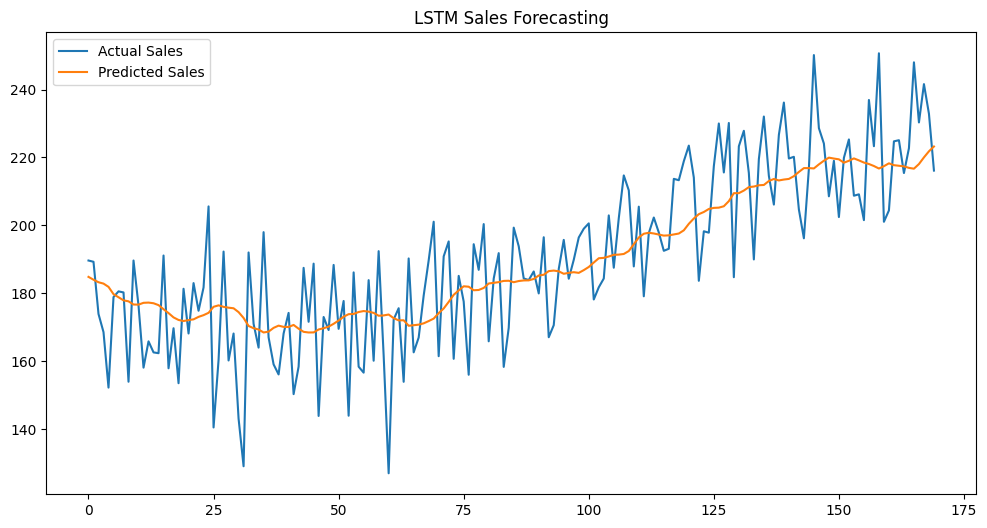

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(actual_sales, label="Actual Sales")
plt.plot(pred_sales, label="Predicted Sales")
plt.legend()
plt.title("LSTM Sales Forecasting")
plt.show()
